# モデル評価(LightGBM)

学習済みモデルの性能および特徴量影響度を確認するフェーズです。

## 実施内容
* 学習データの推論結果読込
* 各種メトリクス算出（AUC, Precision, Recall, F1, MCC, NDCG, Hit Rate）
* 評価結果のCSV出力
* 特徴量重要度分析と出力
* SHAP分析と出力

## 1. ライブラリインポート

In [ ]:
# 標準ライブラリ
import logging
import time
import warnings
from datetime import datetime
from functools import wraps
from pathlib import Path
from typing import Any, Callable, Dict, Tuple

# サードパーティライブラリ
import lightgbm as lgb
import numpy as np
import polars as pl
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    matthews_corrcoef,
    ndcg_score,
    roc_auc_score,
)
from tqdm.auto import tqdm
import shapely

# 自作モジュール
from utils_copy import(
    timing_decorator,
    get_latest_output_dir,
    load_data_pl,
    load_data_pl,
    recall_at_k,
    precision_at_k,
    mcc_score,
    ndcg_at_k,
    hit_rate_at_k,
    compute_metrics,
    get_feature_importance,
    to_categorical,
    compute_shap_values,
    save_csvs
)

# ロガー設定
# python規約9.4のlogging_config.pyを参考に、loggerを設定
# INFO以上(INFO, WARNING, ERROR, CRITICAL)を出力
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

warnings.filterwarnings('default')

logger.info("ライブラリのインポート完了")

2026-06-10 23:33:16,427 - INFO - ライブラリのインポート完了


In [137]:
# ==共通化== →utils.py
# 実行時間を記録

def timing_decorator(func: Callable) -> Callable:
    """関数の実行時間を計測してログ出力するデコレータ。"""

    @wraps(func)
    def wrapper(*args: Any, **kwargs: Any) -> Any:
        start_time: float = time.time()
        try:
            result = func(*args, **kwargs)
        except Exception:
            logger.exception(f"{func.__name__} でエラーが発生しました")
            raise
        elapsed_time: float = time.time() - start_time
        logger.info(f"{func.__name__} 実行時間: {elapsed_time:.2f}秒")
        return result
    return wrapper

## 2. パス設定
* 入力・出力ファイルのパスを定義する
* 03で作成したタイムスタンプ付き出力ディレクトリを参照する
* モデル・パラメータを読み込み、評価結果の成果物を保存する

In [138]:
# ==共通化== →utils.py
# 最新のoutputディレクトリを取得

@timing_decorator
def get_latest_output_dir(base_dir: str = "../output") -> Tuple[Path, str]:
    base = Path(base_dir)
    dirs = [d for d in base.iterdir() if d.is_dir()]

    if not dirs:
        raise FileNotFoundError("No output directories found.")

    latest = max(dirs, key=lambda d: d.name)
    timestamp = latest.name
    return latest, timestamp


In [179]:
# ディレクトリ
# OUTPUT_DIR, OUTPUT_TIMESTAMP = get_latest_output_dir()
OUTPUT_DIR = "../output/2606101938"

logger.info(f"使用する出力ディレクトリ: {OUTPUT_DIR}")
ARTIFACT_DIR: str = f"{OUTPUT_DIR}/artifacts"
MODEL_DIR: str = f"{OUTPUT_DIR}/model"


OUTPUT_TIMESTAMP = "2606101938"

# 入力
X_TRAIN_FILE: str = "../data/X_train.csv"
X_VALID_FILE: str = "../data/X_valid.csv"
# 予測結果
PREDICTION_RESULT_FILE: str = (
    f"{OUTPUT_DIR}/prediction_result_{OUTPUT_TIMESTAMP}.csv"
)
# モデル
MODEL_BASELINE_FILE: str = (
    f"{MODEL_DIR}/model_baseline_{OUTPUT_TIMESTAMP}.lgbm"
)
MODEL_TUNED_FILE: str = (
    f"{MODEL_DIR}/model_tuned_{OUTPUT_TIMESTAMP}.lgbm"
)


# 出力
# 評価結果
EVALUATION_BASELINE_FILE: str = (
    f"{ARTIFACT_DIR}/evaluation_baseline_metrics_{OUTPUT_TIMESTAMP}.csv"
)
EVALUATION_TUNED_FILE: str = (
    f"{ARTIFACT_DIR}/evaluation_tuned_metrics_{OUTPUT_TIMESTAMP}.csv"
)
EVALUATION_COMPARISON_FILE: str = (
    f"{ARTIFACT_DIR}/evaluation_comparison_{OUTPUT_TIMESTAMP}.csv"
)

# 特徴量重要度
FEATURE_IMPORTANCE_BASELINE_FILE: str = (
    f"{ARTIFACT_DIR}/feature_importance_baseline_{OUTPUT_TIMESTAMP}.csv"
)
FEATURE_IMPORTANCE_TUNED_FILE: str = (
    f"{ARTIFACT_DIR}/feature_importance_tuned_{OUTPUT_TIMESTAMP}.csv"
)

# SHAP
SHAP_BASELINE_FILE: str = (
    f"{ARTIFACT_DIR}/shap_baseline_{OUTPUT_TIMESTAMP}.csv"
)
SHAP_TUNED_FILE: str = (
    f"{ARTIFACT_DIR}/shap_tuned_{OUTPUT_TIMESTAMP}.csv"
)

2026-06-10 23:52:27,897 - INFO - 使用する出力ディレクトリ: ../output/2606101938


## 3. 変数定義
* 評価に使用する変数を定義

In [142]:
# 評価指標(何番までで評価するか)
TOP_K = 10

# 閾値
threshold = 0.5

# データ読み込み時のチャンクサイズ
CHUNK_SIZE = 1000

## 4. データ読み込み

In [143]:
# ==共通化== →utils.py
# データの読み込み（チャンク化して進捗バー表示）
@timing_decorator
def load_data_pl(path: str, chunk_size: int) -> pl.DataFrame:
    batches = pl.scan_csv(path).collect_batches(chunk_size=chunk_size)
    chunks = list(tqdm(batches))
    return pl.concat(chunks)

In [144]:
# 予測結果の読み込み
df_predictions = load_data_pl(PREDICTION_RESULT_FILE, CHUNK_SIZE)

0it [00:00, ?it/s]

2026-06-10 23:34:56,137 - INFO - load_data_pl 実行時間: 0.14秒


## 5. モデル評価
* 各評価指標の関数を定義
* 評価指標の計算
* 評価指標の保存


### 5.1 各評価指標の関数

In [146]:
# 共通化
# モジュール化候補
@timing_decorator
def recall_at_k(y_true: np.ndarray, y_pred_proba: np.ndarray, k: int) -> float:
    """Recall@Kを計算

    Args:
        y_true: 真のラベル
        y_score: 予測スコア
        k: 上位K件

    Returns:
        Recall@K
    """
    idx: np.ndarray = np.argsort(-y_pred_proba)[:k]
    return float(y_true[idx].sum() / y_true.sum())


@timing_decorator
def precision_at_k(y_true: np.ndarray, y_pred_proba: np.ndarray, k: int) -> float:
    """Precision@Kを計算

    Args:
        y_true: 真のラベル
        y_score: 予測スコア
        k: 上位K件

    Returns:
        Precision@K
    """
    idx: np.ndarray = np.argsort(-y_pred_proba)[:k]
    return float(y_true[idx].sum() / k)


@timing_decorator
def mcc_score(y_true: np.ndarray, y_pred_label: np.ndarray) -> float:
    """Matthews Correlation Coefficientを計算

    Args:
        y_true: 真のラベル
        y_pred: 予測ラベル

    Returns:
        MCC
    """
    return float(matthews_corrcoef(y_true, y_pred_label))


@timing_decorator
def ndcg_at_k(y_true: np.ndarray, y_pred_proba: np.ndarray, k: int) -> float:
    """NDCG@Kを計算

    Args:
        y_true: 真のラベル
        y_score: 予測スコア
        k: 上位K件

    Returns:
        NDCG@K
    """
    y_true_2d: np.ndarray = y_true.reshape(1, -1)
    y_score_2d: np.ndarray = y_pred_proba.reshape(1, -1)
    return float(ndcg_score(y_true_2d, y_score_2d, k=k))


@timing_decorator
def hit_rate_at_k(y_true: np.ndarray, y_pred_proba: np.ndarray, k: int) -> float:
    """Hit Rate@Kを計算

    Args:
        y_true: 真のラベル
        y_score: 予測スコア
        k: 上位K件

    Returns:
        Hit Rate@K
    """
    idx: np.ndarray = np.argsort(-y_pred_proba)[:k]
    return 1.0 if y_true[idx].sum() > 0 else 0.0

### 5.2 評価関数の計算
* y, y_pred_label, y_pred_probaを入力とし、metricsの辞書を返す

In [147]:
# 共通化

@timing_decorator
def compute_metrics(
    y: np.ndarray,
    y_pred_proba: np.ndarray,
    y_pred_label: np.ndarray,
    top_k: int
) -> Dict[str, Any]:

    metrics: Dict[str, Any] = {
        "auc": roc_auc_score(y, y_pred_proba),
        f"recall_at_{top_k}": recall_at_k(y, y_pred_proba, top_k),
        f"precision_at_{top_k}": precision_at_k(y, y_pred_proba, top_k),
        "mcc": mcc_score(y, y_pred_label),
        f"ndcg_at_{top_k}": ndcg_at_k(y, y_pred_proba, top_k),
        f"hit_rate_at_{top_k}": hit_rate_at_k(y, y_pred_proba, top_k),
    }

    return metrics

In [148]:
# baselineモデル評価
y: np.ndarray = df_predictions["y"].to_numpy()

y_pred_proba_baseline: np.ndarray = df_predictions["y_baseline_proba"].to_numpy()
y_pred_label_baseline: np.ndarray = df_predictions["y_baseline_pred"].to_numpy()

# threshold（必要なら）
y_pred_binary_baseline: np.ndarray = (y_pred_proba_baseline > threshold).astype(int)

In [149]:
# baselineモデル評価
metrics_baseline = compute_metrics(
    y=y,
    y_pred_proba=y_pred_proba_baseline,
    y_pred_label=y_pred_label_baseline,
    top_k=TOP_K
)

2026-06-10 23:35:08,357 - INFO - recall_at_k 実行時間: 0.00秒
2026-06-10 23:35:08,357 - INFO - precision_at_k 実行時間: 0.00秒
2026-06-10 23:35:08,365 - INFO - mcc_score 実行時間: 0.01秒
2026-06-10 23:35:08,368 - INFO - ndcg_at_k 実行時間: 0.00秒
2026-06-10 23:35:08,368 - INFO - hit_rate_at_k 実行時間: 0.00秒
2026-06-10 23:35:08,369 - INFO - compute_metrics 実行時間: 0.06秒


In [150]:
# tunedモデル評価
y: np.ndarray = df_predictions["y"].to_numpy()

y_pred_proba_tuned: np.ndarray = df_predictions["y_tuned_proba"].to_numpy()
y_pred_label_tuned: np.ndarray = df_predictions["y_tuned_pred"].to_numpy()

# threshold（必要なら）
y_pred_binary_tuned: np.ndarray = (y_pred_proba_tuned > threshold).astype(int)

In [151]:
metrics_tuned = compute_metrics(
    y=y,
    y_pred_proba=y_pred_proba_tuned,
    y_pred_label=y_pred_label_tuned,
    top_k=TOP_K
)

2026-06-10 23:35:13,876 - INFO - recall_at_k 実行時間: 0.00秒
2026-06-10 23:35:13,910 - INFO - precision_at_k 実行時間: 0.01秒
2026-06-10 23:35:13,963 - INFO - mcc_score 実行時間: 0.05秒
2026-06-10 23:35:13,972 - INFO - ndcg_at_k 実行時間: 0.00秒
2026-06-10 23:35:13,973 - INFO - hit_rate_at_k 実行時間: 0.00秒
2026-06-10 23:35:13,973 - INFO - compute_metrics 実行時間: 0.11秒


### 5.3 評価結果の保存

In [186]:
@timing_decorator


def save_csvs(files: Dict[str, pd.DataFrame | pl.DataFrame]) -> None:
    for file_path, df in files.items():

        # Polars DataFrame
        if isinstance(df, pl.DataFrame):
            df.write_csv(file_path)

        # pandas DataFrame
        elif isinstance(df, pd.DataFrame):
            df.to_csv(file_path, index=False)

        else:
            raise TypeError(f"Unsupported type: {type(df)}")

        logger.info("%s 保存完了", file_path)

In [153]:
df_metrics_baseline = pl.DataFrame([metrics_baseline])
df_metrics_tuned = pl.DataFrame([metrics_tuned])
df_metrics_comparison = pl.concat([df_metrics_baseline, df_metrics_tuned])
save_csvs({
    EVALUATION_BASELINE_FILE: df_metrics_baseline,
    EVALUATION_TUNED_FILE: df_metrics_tuned,
    EVALUATION_COMPARISON_FILE: df_metrics_comparison,
})

2026-06-10 23:35:18,532 - INFO - ../output/2606101938/artifacts/evaluation_baseline_metrics_2606101938.csv 保存完了
2026-06-10 23:35:18,534 - INFO - ../output/2606101938/artifacts/evaluation_tuned_metrics_2606101938.csv 保存完了
2026-06-10 23:35:18,538 - INFO - ../output/2606101938/artifacts/evaluation_comparison_2606101938.csv 保存完了
2026-06-10 23:35:18,538 - INFO - save_csvs 実行時間: 0.02秒


## 6. 特徴量重要度分析
* 03で学習済みのモデルを読み込む
* LightGBMモデルを用いて特徴量重要度の分析を実施する
* 特徴量重要度分析の結果を保存する

### 6.1 学習済モデル読み込み
* 特徴量重要度・SHAP分析用にlgbm形式モデルも読み込む

In [ ]:
# lgbmモデル読み込み（特徴量重要度・SHAP分析用）
model_baseline = lgb.Booster(model_file=MODEL_BASELINE_FILE)
model_tuned = lgb.Booster(model_file=MODEL_TUNED_FILE)  
logger.info("lgbmモデル読み込み完了")

2026-06-10 23:34:58,778 - INFO - lgbmモデル読み込み完了


### 6.2 特徴量重要度分析の実施

In [158]:
@timing_decorator
def get_feature_importance(
    model: lgb.Booster,
    feature_names: list,
    model_name: str,
    top_n: int = 20
) -> pl.DataFrame:

    # 特徴量重要度取得
    importance: np.ndarray = model.feature_importance(importance_type='gain')
    
    importance = importance / importance.sum()
    
    importance_df: pl.DataFrame = pl.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort("importance", descending=True)
    
    
    # 上位N件表示
    print(f"\n{'='*70}")
    print(f"{model_name}モデル - 特徴量重要度 Top {top_n}")
    print(f"{'='*70}")
    print(importance_df.head(top_n))
    
    return importance_df

In [159]:
X_valid = load_data_pl(X_VALID_FILE, CHUNK_SIZE)

0it [00:00, ?it/s]

2026-06-10 23:36:43,491 - INFO - load_data_pl 実行時間: 0.02秒


In [160]:
feature_names: list = X_valid.columns

# baselineモデルFI
importance_baseline: pl.DataFrame = get_feature_importance(
    model=model_baseline,
    feature_names=feature_names,
    model_name="baseline",
    top_n=20
)

# tunedモデルFI
importance_tuned: pl.DataFrame = get_feature_importance(
    model=model_tuned,
    feature_names=feature_names,
    model_name="tuned",
    top_n=20
)

2026-06-10 23:36:43,812 - INFO - get_feature_importance 実行時間: 0.01秒
2026-06-10 23:36:43,814 - INFO - get_feature_importance 実行時間: 0.00秒



baselineモデル - 特徴量重要度 Top 20
shape: (17, 2)
┌───────────┬────────────┐
│ feature   ┆ importance │
│ ---       ┆ ---        │
│ str       ┆ f64        │
╞═══════════╪════════════╡
│ duration  ┆ 0.449473   │
│ month     ┆ 0.138437   │
│ poutcome  ┆ 0.09729    │
│ contact   ┆ 0.054189   │
│ day       ┆ 0.053024   │
│ …         ┆ …          │
│ marital   ┆ 0.008176   │
│ previous  ┆ 0.005415   │
│ loan      ┆ 0.003811   │
│ education ┆ 0.002735   │
│ default   ┆ 0.001884   │
└───────────┴────────────┘

tunedモデル - 特徴量重要度 Top 20
shape: (17, 2)
┌───────────┬────────────┐
│ feature   ┆ importance │
│ ---       ┆ ---        │
│ str       ┆ f64        │
╞═══════════╪════════════╡
│ duration  ┆ 0.390803   │
│ month     ┆ 0.131704   │
│ poutcome  ┆ 0.094736   │
│ day       ┆ 0.062402   │
│ contact   ┆ 0.05798    │
│ …         ┆ …          │
│ marital   ┆ 0.01013    │
│ loan      ┆ 0.007097   │
│ previous  ┆ 0.006838   │
│ education ┆ 0.001735   │
│ default   ┆ 0.001686   │
└───────────┴───────────

### 6.3 特徴量重要度分析の結果保存

In [161]:
save_csvs({
    FEATURE_IMPORTANCE_BASELINE_FILE: importance_baseline,
    FEATURE_IMPORTANCE_TUNED_FILE: importance_tuned,
})

2026-06-10 23:36:46,492 - INFO - ../output/2606101938/artifacts/feature_importance_baseline_2606101938.csv 保存完了
2026-06-10 23:36:46,495 - INFO - ../output/2606101938/artifacts/feature_importance_tuned_2606101938.csv 保存完了
2026-06-10 23:36:46,495 - INFO - save_csvs 実行時間: 0.01秒


## 7. SHAP値分析
* SHAP (SHapley Additive exPlanations) を使用してモデルの予測を解釈
* SHAP値分析の結果を保存

In [164]:
from dataclasses import dataclass
from typing import List

@dataclass
class FeatureSchema:
    target: str
    num_cols: List[str]
    cat_cols: List[str]
    
schema = FeatureSchema(
    target="label",
    num_cols=['id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'],
    cat_cols= ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']   
)

In [165]:
# ==共通化== →utils.py
# データの読み込み（チャンク化して進捗バー表示）
import pandas as pd
@timing_decorator
def load_data_pd(path: str, chunk_size: int) -> pd.DataFrame:
    chunks = []
    for chunk in tqdm(pd.read_csv(path, chunksize=chunk_size)):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

In [166]:
X_valid = load_data_pd(X_VALID_FILE, CHUNK_SIZE)

0it [00:00, ?it/s]

2026-06-10 23:42:15,066 - INFO - load_data_pd 実行時間: 0.09秒


In [171]:
def to_categorical(df, cat_cols):
    for col in cat_cols:
        df[col] = df[col].astype("category")
    return df

### 7.1 SHAP分析の実施

In [175]:
def compute_shap_values(model, X):
    explainer = shap.TreeExplainer(model)
    logger.info("Expected value: %s", explainer.expected_value)

    shap_values = explainer.shap_values(X)
    logger.info("X_valid shape     : %s", X_valid.shape)
    logger.info("shap_values shape : %s", shap_values.shape)

    shap.summary_plot(shap_values, X_valid, feature_names=X_valid.columns.tolist())

    return shap_values, explainer.expected_value


2026-06-10 23:55:27,468 - INFO - Expected value: [-3.76265188]
/Users/aa539999/.pyenv/versions/3.10.18/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
2026-06-10 23:55:27,629 - INFO - X_valid shape     : (5426, 17)
2026-06-10 23:55:27,629 - INFO - shap_values shape : (5426, 17)


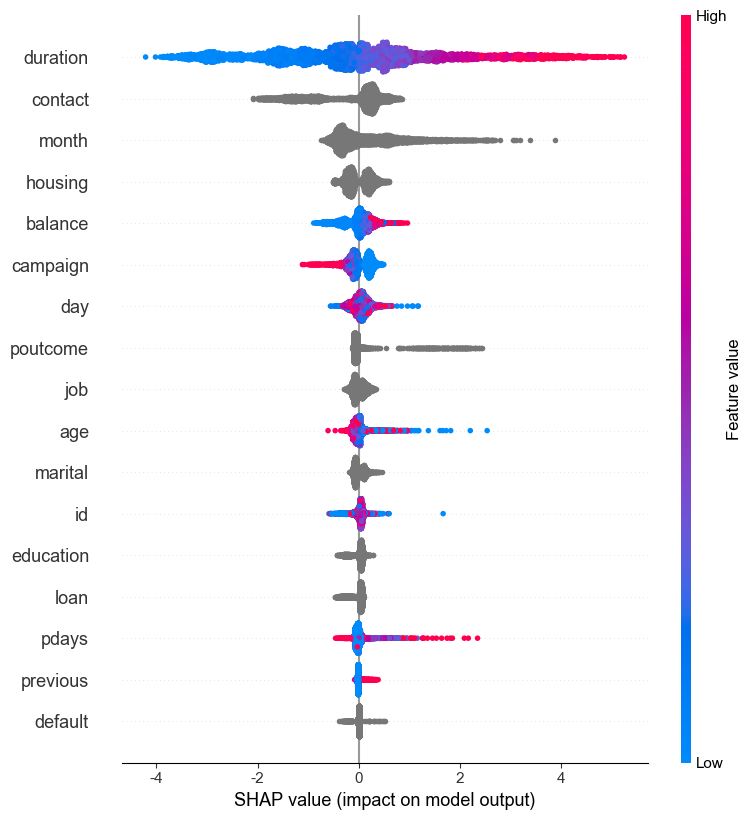

2026-06-10 23:55:28,196 - INFO - Expected value: [-3.48542052]
/Users/aa539999/.pyenv/versions/3.10.18/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
2026-06-10 23:55:28,742 - INFO - X_valid shape     : (5426, 17)
2026-06-10 23:55:28,742 - INFO - shap_values shape : (5426, 17)


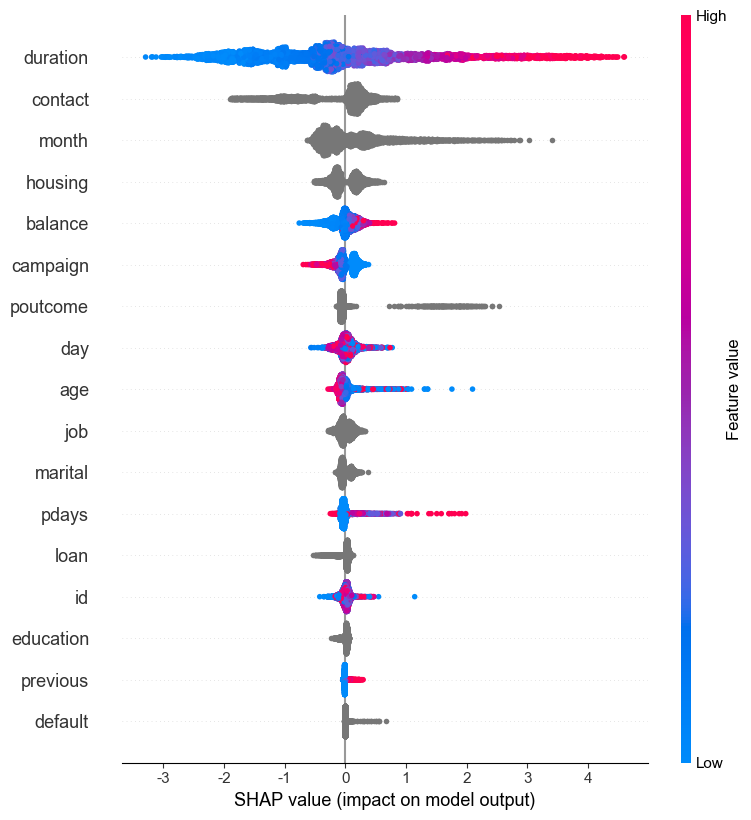

In [ ]:
# baselineモデルSHAP
shap_values_baseline, base_value_baseline = compute_shap_values(model_baseline, X_valid)

# tuneedモデルSHAP
shap_values_tuned, base_value_tuned = compute_shap_values(model_tuned, X_valid)


### 7.2 SHAP分析結果の保存

In [ ]:
df_shap_baseline = pd.DataFrame(shap_values_baseline, columns=X_valid.columns)
df_shap_tuned = pd.DataFrame(shap_values_tuned, columns=X_valid.columns)

save_csvs({
    SHAP_BASELINE_FILE: df_shap_baseline,
    SHAP_TUNED_FILE: importance_tuned,
})


2026-06-11 00:00:05,870 - INFO - ../output/2606101938/artifacts/shap_baseline_2606101938.csv 保存完了
2026-06-11 00:00:05,875 - INFO - ../output/2606101938/artifacts/shap_tuned_2606101938.csv 保存完了
2026-06-11 00:00:05,875 - INFO - save_csvs 実行時間: 0.09秒
